# Shea Homes Customer Review Analysis
### Customer Insights with Sentiment Analysis
---

**Data Source:** https://www.newhomesource.com/builder/shea-homes/reviews/612/

**Dataset**: 2,039 verified homebuyer reviews (Sept 2020 - March 2026)

**Author**: Griffin Snider

## What This Report Does

This report uses nlp tools to read and analyze every Shea Homes customer review.

Specifically:

This project analyzes 2,039 customer reviews of Shea Homes collected from NewHomeSource.com. NewHomeSource is a review platform where verified homebuyers rate their builder after closing. Each review includes an overall star rating (1-5) plus four sub-ratings: Quality, Trustworthiness, Value, and Responsiveness. Buyers also write open-ended comments describing their experience. This dataset contains reviews for Shea Homes collected between September 2020 and March 2026, covering 11 markets across Arizona, California, Colorado, Nevada, North Carolina, Texas, Washington, and more.

Reading 2,039 reviews manually would take weeks. Even then, it would be hard to spot patterns consistently, like which markets are struggling, what topics keep coming up in negative reviews, or which customers might be at risk of leaving bad word-of-mouth. This project automates that work using a multi-method Natural Language Processing (NLP) framework.

The pipeline includes: \
(1) sentiment classification using VADER (Valence Aware Dictionary and sEntiment Reasoner), a rule-based model tuned for customer review text \
(2) topic extraction using TF-IDF (Term Frequency-Inverse Document Frequency) vectorization and LDA (Latent Dirichlet Allocation), which surface recurring themes without predefined categories \
(3) predictive modeling using machine learning classifiers to flag at-risk reviews \
(4) contextual analysis using a locally-deployed large language model (LLaMA 3.2 via Ollama) that reads individual reviews and generates recommendations

---
## Setup

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from scipy import stats
import re
import warnings
warnings.filterwarnings("ignore")

# nlp tools
import nltk
nltk.download("vader_lexicon", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob
from wordcloud import WordCloud
import spacy

#ml
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.pipeline import Pipeline

# visual style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
SHEA_BLUE = "#1a5276"
SHEA_GOLD = "#d4a843"
SHEA_PALETTE = ["#c0392b", "#e67e22", "#f1c40f", "#27ae60", "#1a5276"]

# keep apostrophes so contractions like "don't" stay as one token
TOKEN_PATTERN = r"(?u)\b\w[\w']+\b"

In [65]:
# load the dataset
df = pd.read_csv("../shea_homes_reviews.csv", encoding="utf-8-sig")
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print(f"{len(df):,} reviews")
print(f"Date range: {df['date'].min().strftime('%B %Y')} to {df['date'].max().strftime('%B %Y')}")
df.head(3)

2,052 reviews
Date range: September 2020 to April 2026


,title,reviewer_name,verified_homebuyer,date,location,review_text,total_score,quality,trustworthiness,value,responsiveness
0,Good overall,Constance G.,Yes,2026-04-01,"OCALA, FL",A little overwhelming for me as a single elder...,5,5,5,5,5
1,"Excellent, knowledgeable and responsive",Emily V.,Yes,2026-03-31,"Littleton, CO",Our experience exceeded our expectations. The ...,5,5,5,5,5
2,Overall great experience!,Lynn S.,Yes,2026-03-26,"Kuna, ID",This is our second Shea home! Our whole proces...,5,5,5,5,5


---
# Part 1: Summary Statistics

Before applying modeling or artificial intelligence methods, the analysis begins with summary statistics. This step looks at the basic structure of the dataset, including the total number of reviews, how ratings are distributed across the 1–5 star scale, which states and cities generate the most feedback, and the typical length of customer reviews. Establishing these baseline patterns provides context for the more advanced analyses that follow.

## 1.1 Overview

In [67]:
# text metrics
# tokens
df["word_count"] = df["review_text"].apply(lambda x: len(str(x).split()))
df["char_count"] = df["review_text"].apply(lambda x: len(str(x)))

# build a vocabulary
all_words = " ".join(df["review_text"].astype(str)).lower().split()
all_words_clean = [re.sub(r"[^a-z']", "", w) for w in all_words]
all_words_clean = [w for w in all_words_clean if w]
vocab = set(all_words_clean)

# geography
df["state"] = df["location"].str.extract(r",\s*([A-Z]{2})$")
df["year"] = df["date"].dt.year

# display the overview
print("=" * 55)
print("              SHEA HOMES REVIEW DATASET          ")
print("=" * 55)
print(f"  Total reviews:              {len(df):>8,}")
print(f"  Total Tokens:               {sum(df['word_count']):>8,}")
print(f"  Unique words:               {len(vocab):>8,}")
print(f"  Average review length:      {df['word_count'].mean():>8.1f} words")
print(f"  Median review length:       {df['word_count'].median():>8.0f} words")
print(f"  Shortest review:            {df['word_count'].min():>8} words")
print(f"  Longest review:             {df['word_count'].max():>8} words")
print(f"  Unique cities:              {df['location'].nunique():>8}")
print(f"  States covered:             {df['state'].nunique():>8}")
print("=" * 55)

              SHEA HOMES REVIEW DATASET          
  Total reviews:                 2,052
  Total Tokens:                119,117
  Unique words:                  7,088
  Average review length:          58.0 words
  Median review length:             35 words
  Shortest review:                   2 words
  Longest review:                 1092 words
  Unique cities:                    75
  States covered:                   11


## 1.2 Star Rating Distribution

This section shows how customers rated their experience on a 1 to 5 star scale. The left chart counts how many reviews fell at each star level. The right chart shows the average score across five different rating categories that customers fill out: Overall, Quality, Trustworthiness, Value, and Responsiveness.

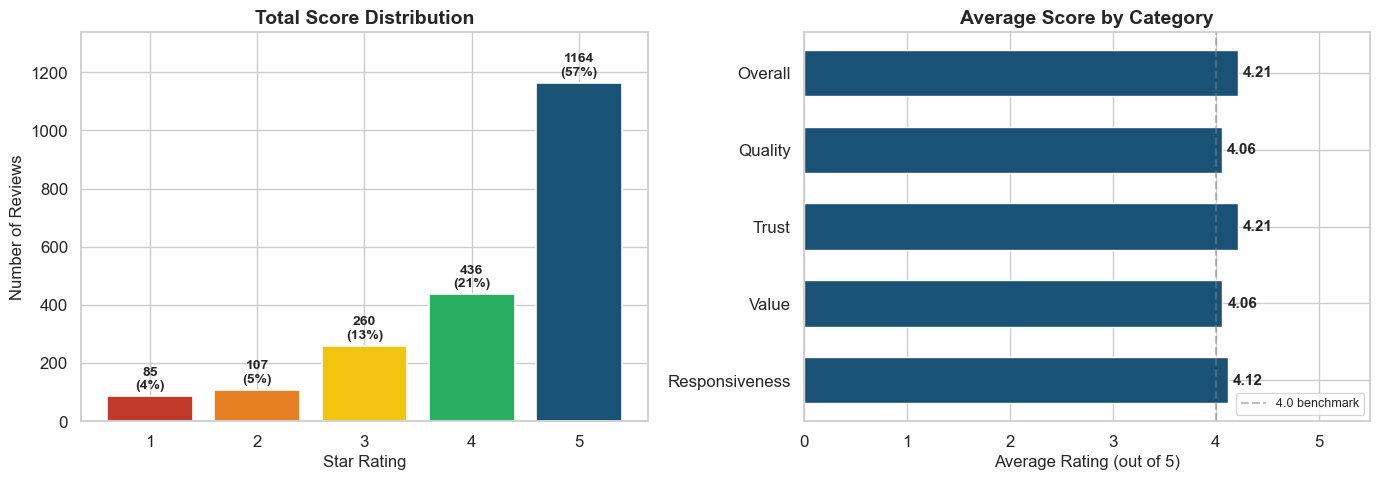

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: Total score distribution
score_counts = df["total_score"].value_counts().sort_index()
bars = axes[0].bar(score_counts.index, score_counts.values, color=SHEA_PALETTE, edgecolor="white", linewidth=1.2)

axes[0].set_ylim(0, score_counts.max() * 1.15)

for bar, val in zip(bars, score_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 f"{val}\n({val/len(df):.0%})", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[0].set_xlabel("Star Rating", fontsize=12)
axes[0].set_ylabel("Number of Reviews", fontsize=12)
axes[0].set_title("Total Score Distribution", fontsize=14, fontweight="bold")
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].set_xticklabels(["1", "2", "3", "4", "5"])

# Right: Average by category
categories = ["total_score", "quality", "trustworthiness", "value", "responsiveness"]
cat_labels = ["Overall", "Quality", "Trust", "Value", "Responsiveness"]
cat_means = [df[c].mean() for c in categories]

bars2 = axes[1].barh(cat_labels[::-1], cat_means[::-1], color=SHEA_BLUE, edgecolor="white", height=0.6)
for bar, val in zip(bars2, cat_means[::-1]):
    axes[1].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f"{val:.2f}", ha="left", va="center", fontsize=11, fontweight="bold")
axes[1].set_xlim(0, 5.5)
axes[1].set_xlabel("Average Rating (out of 5)", fontsize=12)
axes[1].set_title("Average Score by Category", fontsize=14, fontweight="bold")
axes[1].axvline(x=4.0, color="gray", linestyle="--", alpha=0.5, label="4.0 benchmark")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 1.3 Review Volume Over Time

This chart tracks review activity and customer satisfaction over time. The blue bars show the number of reviews submitted each month, representing review volume. The gold line shows the three-month rolling average star rating, which smooths short-term fluctuations to highlight broader trends in customer satisfaction.


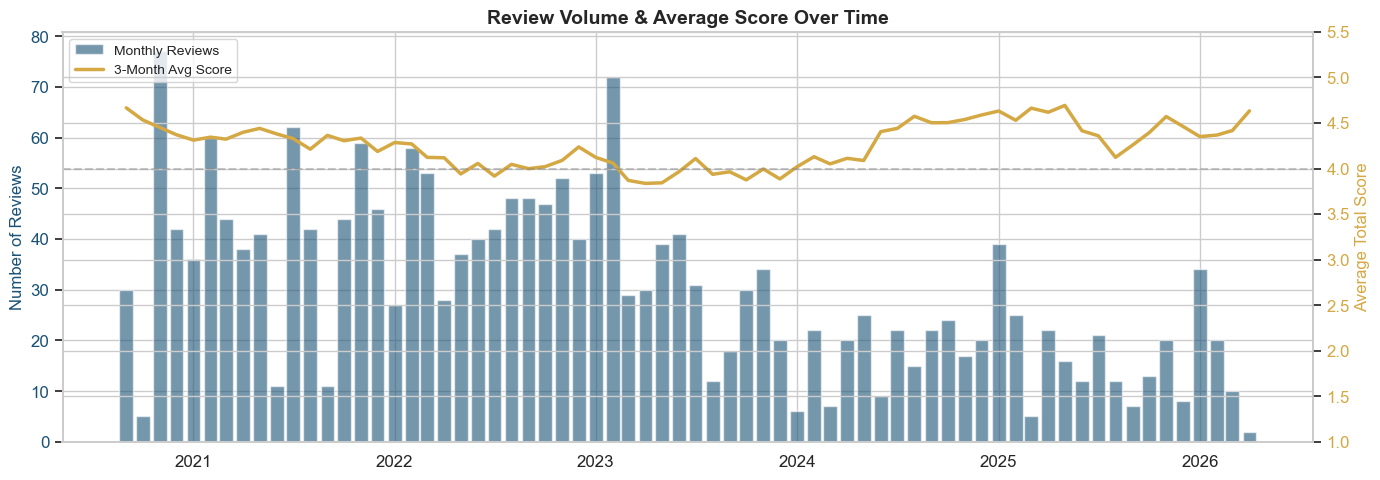

In [72]:
# monthly review volume and rolling average score
df["year_month"] = df["date"].dt.to_period("M")
monthly = df.groupby("year_month").agg(
    review_count=("total_score", "count"),
    avg_score=("total_score", "mean")
).reset_index()
monthly["year_month"] = monthly["year_month"].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(14, 5))

# bar chart for volume
ax1.bar(monthly["year_month"], monthly["review_count"], width=25, color=SHEA_BLUE, alpha=0.6, label="Monthly Reviews")
ax1.set_ylabel("Number of Reviews", fontsize=12, color=SHEA_BLUE)
ax1.set_xlabel("")
ax1.tick_params(axis="y", labelcolor=SHEA_BLUE)

# line chart for average score
ax2 = ax1.twinx()
ax2.plot(monthly["year_month"], monthly["avg_score"].rolling(3, min_periods=1).mean(),
         color=SHEA_GOLD, linewidth=2.5, marker="", label="3-Month Avg Score")
ax2.set_ylabel("Average Total Score", fontsize=12, color=SHEA_GOLD)
ax2.set_ylim(1, 5.5)
ax2.tick_params(axis="y", labelcolor=SHEA_GOLD)
ax2.axhline(y=4.0, color="gray", linestyle="--", alpha=0.4)

# combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=10)

plt.title("Review Volume & Average Score Over Time", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 1.4 Geographic Breakdown

These charts examine the geographic distribution of customer feedback. The left chart shows the number of reviews submitted from each state, showing where the largest share of customer feedback originates. The right chart shows the average star rating by state, calculated only for states with at least 10 reviews.

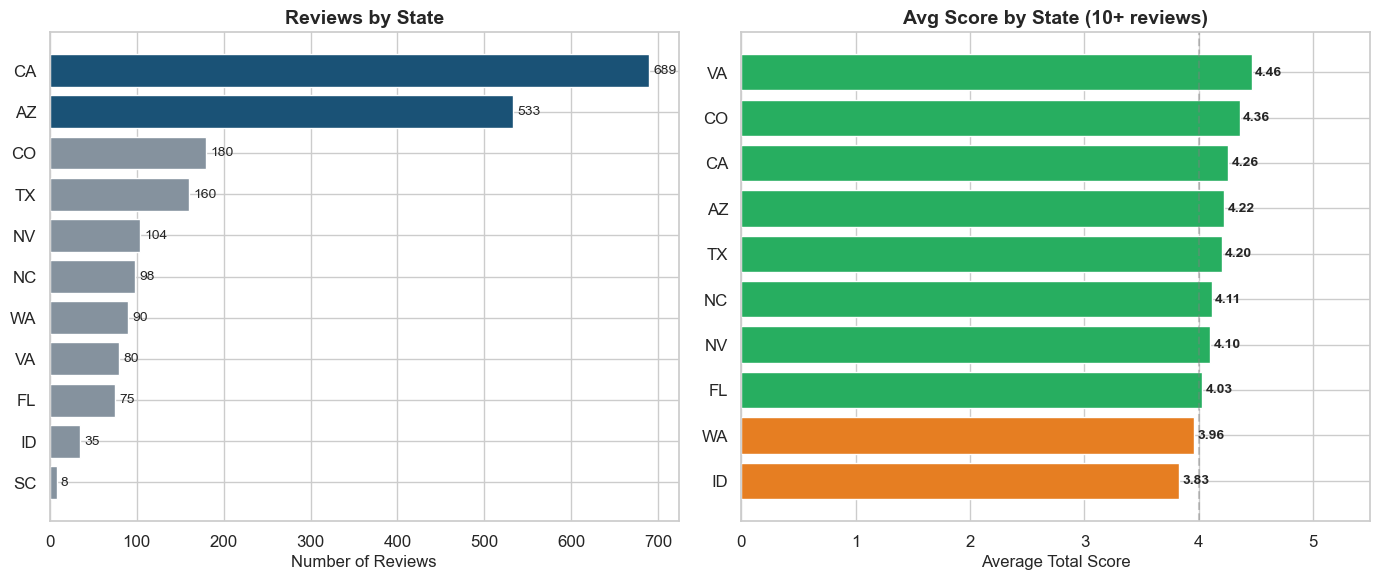

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: Reviews by state ---
state_counts = df["state"].value_counts()
colors = [SHEA_BLUE if s in ["CA", "AZ"] else "#85929e" for s in state_counts.index]
bars = axes[0].barh(state_counts.index[::-1], state_counts.values[::-1],
                     color=colors[::-1], edgecolor="white")
for bar, val in zip(bars, state_counts.values[::-1]):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 str(val), ha="left", va="center", fontsize=10)
axes[0].set_xlabel("Number of Reviews", fontsize=12)
axes[0].set_title("Reviews by State", fontsize=14, fontweight="bold")

# --- Right: Avg score by state ---
state_scores = df.groupby("state")["total_score"].agg(["mean", "count"]).sort_values("mean", ascending=True)
state_scores = state_scores[state_scores["count"] >= 10]  # only states with 10+ reviews
bar_colors = ["#27ae60" if m >= 4.0 else "#e67e22" if m >= 3.0 else "#c0392b" for m in state_scores["mean"]]
bars2 = axes[1].barh(state_scores.index, state_scores["mean"], color=bar_colors, edgecolor="white")
for bar, val in zip(bars2, state_scores["mean"]):
    axes[1].text(bar.get_width() + 0.03, bar.get_y() + bar.get_height()/2,
                 f"{val:.2f}", ha="left", va="center", fontsize=10, fontweight="bold")
axes[1].set_xlim(0, 5.5)
axes[1].set_xlabel("Average Total Score", fontsize=12)
axes[1].set_title("Avg Score by State (10+ reviews)", fontsize=14, fontweight="bold")
axes[1].axvline(x=4.0, color="gray", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## 1.5 Top Cities & Review Length Analysis

This chart identifies the cities that generate the largest volume of customer reviews. Each bar represents the number of reviews submitted from a specific city.


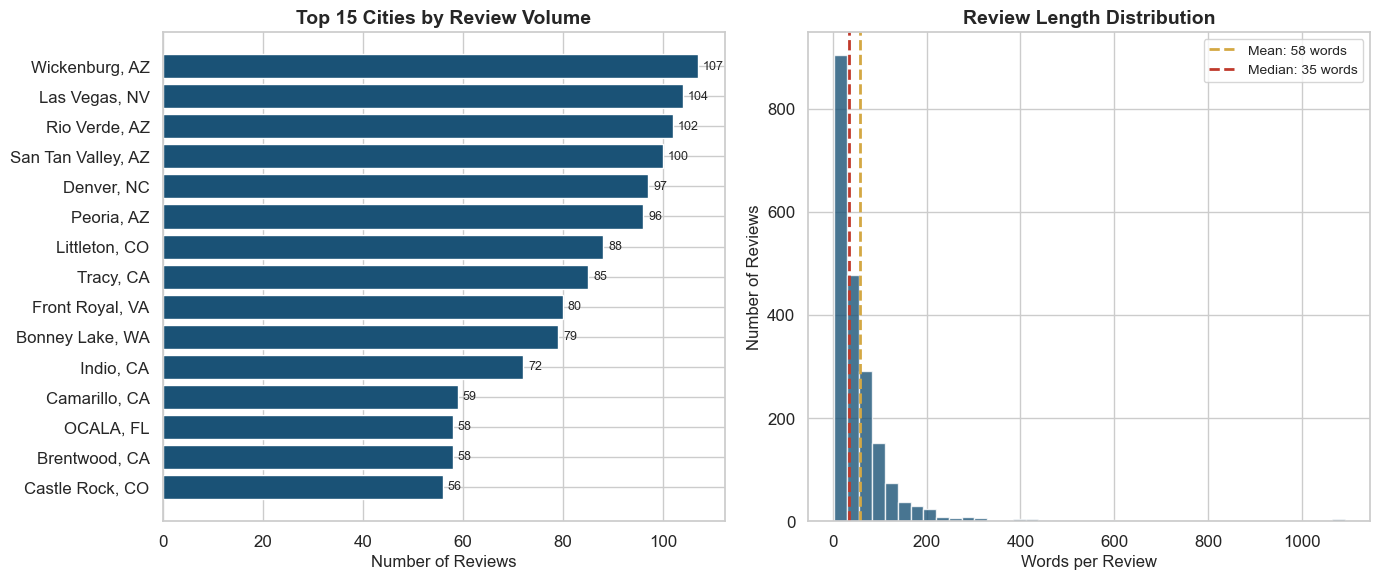

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: Top 15 cities ---
top_cities = df["location"].value_counts().head(15)
axes[0].barh(top_cities.index[::-1], top_cities.values[::-1], color=SHEA_BLUE, edgecolor="white")
for i, (val, city) in enumerate(zip(top_cities.values[::-1], top_cities.index[::-1])):
    axes[0].text(val + 1, i, str(val), ha="left", va="center", fontsize=9)
axes[0].set_xlabel("Number of Reviews", fontsize=12)
axes[0].set_title("Top 15 Cities by Review Volume", fontsize=14, fontweight="bold")

# --- Right: Review length distribution ---
axes[1].hist(df["word_count"], bins=40, color=SHEA_BLUE, edgecolor="white", alpha=0.8)
axes[1].axvline(df["word_count"].mean(), color=SHEA_GOLD, linewidth=2, linestyle="--",
                label=f"Mean: {df['word_count'].mean():.0f} words")
axes[1].axvline(df["word_count"].median(), color="#c0392b", linewidth=2, linestyle="--",
                label=f"Median: {df['word_count'].median():.0f} words")
axes[1].set_xlabel("Words per Review", fontsize=12)
axes[1].set_ylabel("Number of Reviews", fontsize=12)
axes[1].set_title("Review Length Distribution", fontsize=14, fontweight="bold")
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

Customer feedback is concentrated in a small number of communities. Cities such as Wickenburg, AZ; Las Vegas, NV; Rio Verde, AZ; and San Tan Valley, AZ contribute the highest number of reviews. These locations represent the areas where the dataset contains the most direct customer experience information.

## 1.6 Rating Correlations

This heatmap shows the correlation between the five rating categories: Overall, Quality, Trust, Value, and Responsiveness. Correlation measures how closely two variables move together. Values closer to 1.0 indicate a strong relationship, meaning customers tend to rate those categories similarly.

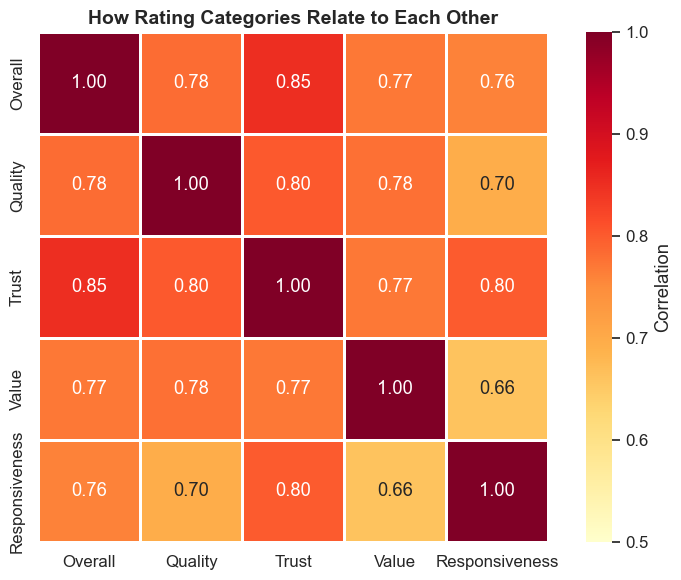

In [80]:
score_cols = ["total_score", "quality", "trustworthiness", "value", "responsiveness"]
score_labels = ["Overall", "Quality", "Trust", "Value", "Responsiveness"]
corr = df[score_cols].corr()
corr.index = score_labels
corr.columns = score_labels

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0.5, vmax=1,
            square=True, linewidths=1, ax=ax, cbar_kws={"label": "Correlation"})
ax.set_title("How Rating Categories Relate to Each Other", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

All categories are highly correlated, showing that customers who rate one dimension poorly tend to rate everything poorly. This suggests the overall experience is somewhat holistic: a bad construction experience drags down trust, value, and responsiveness perceptions too.
